In [1]:
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import pickle as pkl
import matplotlib.pyplot as plt
import os

In [2]:
def match_features_between_frames(frames):
    frame1_path, frame2_path = frames
    img1_bgr = cv2.imread(frame1_path)
    img2_bgr = cv2.imread(frame2_path)

    img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures=3000)
    kp1, des1 = orb.detectAndCompute(img1_gray, None)
    kp2, des2 = orb.detectAndCompute(img2_gray, None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    pairs = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in pairs:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

    M, inliers = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    # translation part:
    dx, dy = float(M[0, 2]), float(M[1, 2])
    frame_dist = (dx*dx + dy*dy) ** 0.5
    return {
        "frame1": str(frame1_path),
        "frame2": str(frame2_path),
        "dist": frame_dist, 
        "n_inliers": inliers.sum()
        }

In [3]:
def get_optical_flow_between_frames(frames):
    frame1_path, frame2_path = frames
    img1_bgr = cv2.imread(frame1_path)
    img2_bgr = cv2.imread(frame2_path)

    img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
    
    p0 = cv2.goodFeaturesToTrack(
        img1_gray,
        maxCorners=1000,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

    n_init_features = int(len(p0))

    p1, st, err = cv2.calcOpticalFlowPyrLK(
        img1_gray,
        img2_gray,
        p0,
        None,
        winSize=(21, 21),
        maxLevel=3,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
    )

    # keep only successfully tracked points
    good = (st.reshape(-1) == 1)
    
    # filter based on error (take 80 percentile)
    e = err.reshape(-1)
    if np.any(good):
        thr = np.percentile(e[good], 80)
        good &= (e <= thr)

    p0_good = p0[good]
    p1_good = p1[good]
    n_good_tracks = int(good.sum())
    track_ratio = n_good_tracks / max(n_init_features, 1)

    if n_good_tracks <= 0:
        raise NotImplementedError("0 good tracks found. No fallback implemented")
    
    lk_err_median = float(np.median(err.reshape(-1)[good]))

    disp_raw = p1_good.reshape(-1, 2) - p0_good.reshape(-1, 2)
    median_flow_magnitude = float(np.median(np.linalg.norm(disp_raw, axis=1))) # median distance the points moved

    # try optical flow backwards to ensure consistency
    p0_back, st_back, _ = cv2.calcOpticalFlowPyrLK(
        img2_gray,
        img1_gray,
        p1_good.reshape(-1, 1, 2),
        None,
        winSize=(21, 21),
        maxLevel=3,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
    )
    
    st_back = st_back.reshape(-1).astype(bool)  # mask of succesful backward tracks
    fb = np.linalg.norm(
        p0_back.reshape(-1, 2)[st_back] - p0_good.reshape(-1, 2)[st_back],
        axis=1,
    )
    fb_err_median = float(np.median(fb))  #median error of backwards track
    
    # good_old, good_new from KLT sparse flow snippet
    p0_good = p0_good.reshape(-1, 2).astype(np.float32)
    p1_good = p1_good.reshape(-1, 2).astype(np.float32)

    F, mask = cv2.findFundamentalMat(
        p0_good,
        p1_good,
        method=cv2.FM_RANSAC,
        ransacReprojThreshold=2.0,
        confidence=0.99
    )  # RANSAC step

    if F is not None and mask is not None:
        inlier_mask = mask.ravel().astype(bool)
        ransac_inlier_ratio = float(inlier_mask.mean())

        inliers1 = p0_good[inlier_mask]
        inliers2 = p1_good[inlier_mask]

        disp = inliers2 - inliers1
        mag = np.linalg.norm(disp, axis=1)
        dist = float(np.median(mag))  # we can use another way to aggregate motion per frame
        # We basically get a better version of median_flow_magnitude defined previously
    else:
        raise RuntimeError("RANSAC failed for KLT points")

    # Print for debugging or maybe accumulate them?

    stats = pd.Series({
        "frame1": frame1_path,
        "frame2": frame2_path,
        "n_init_features" : n_init_features,
        "n_good_tracks" : n_good_tracks,
        "track_ratio" : track_ratio,
        "lk_err_median" : lk_err_median,
        "backward_error" : fb_err_median,
        "median_flow_magnitude" : median_flow_magnitude,
        "ransac_inlier_ratio" : ransac_inlier_ratio,
        "dist" : dist,
    })
    return stats

In [ ]:
def warp_motion_magnitude(warp, shape_hw, grid=40):
    H, W = shape_hw

    xs = np.linspace(0, W - 1, grid, dtype=np.float32)
    ys = np.linspace(0, H - 1, grid, dtype=np.float32)
    xv, yv = np.meshgrid(xs, ys)
    pts = np.stack([xv.reshape(-1), yv.reshape(-1)], axis=1)  # (N,2)

    if warp.shape == (2, 3):
        A = warp[:, :2]
        t = warp[:, 2]
        pts_w = (pts @ A.T) + t
    elif warp.shape == (3, 3):
        pts_h = np.concatenate([pts, np.ones((pts.shape[0], 1), dtype=np.float32)], axis=1)  # (N,3)
        proj = (pts_h @ warp.T)
        pts_w = proj[:, :2] / np.clip(proj[:, 2:3], 1e-6, None)
    else:
        raise ValueError("warp must be 2x3 or 3x3")

    disp = np.linalg.norm(pts_w - pts, axis=1)
    return float(np.median(disp)), float(np.mean(disp))

def ecc_warp(frames, model="affine", iters=200, eps=1e-6, gauss=5):
    frame1_path, frame2_path = frames
    img1_bgr = cv2.imread(frame1_path)
    img2_bgr = cv2.imread(frame2_path)

    img1_bgr = cv2.resize(img1_bgr, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
    img2_bgr = cv2.resize(img2_bgr, (0, 0), fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)

    img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
    # ECC expects float32, typically normalized
    prev = img1_gray.astype(np.float32) / 255.0
    curr = img2_gray.astype(np.float32) / 255.0

    if model == "translation":
        warp_mode = cv2.MOTION_TRANSLATION
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "euclidean":
        warp_mode = cv2.MOTION_EUCLIDEAN
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "affine":
        warp_mode = cv2.MOTION_AFFINE
        warp = np.eye(2, 3, dtype=np.float32)
    elif model == "homography":
        warp_mode = cv2.MOTION_HOMOGRAPHY
        warp = np.eye(3, 3, dtype=np.float32)
    else:
        raise ValueError("unknown model")

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iters, eps)
    
    cc, warp = cv2.findTransformECC(
        templateImage=prev,
        inputImage=curr,
        warpMatrix=warp,
        motionType=warp_mode,
        criteria=criteria,
        inputMask=None,
        gaussFiltSize=gauss
    )
    med_px, mean_px = warp_motion_magnitude(warp, img1_gray.shape, grid=40)
    return med_px, cc


In [5]:
def laplacian_var(image_path):
    bgr = cv2.imread(image_path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def laplacian_var_downsize(image_path):
    bgr = cv2.imread(image_path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(cv2.resize(gray, (0,0), fx=0.25, fy=0.25), cv2.CV_64F).var()

def multiscale_laplacian_var(image_path, levels=3, down=2):
    bgr = cv2.imread(image_path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32) / 255.0

    score = 0.0
    img = gray
    for _ in range(levels):
        lap = cv2.Laplacian(img, cv2.CV_32F, ksize=3)
        score += float(lap.var())
        # downsample for next scale
        h, w = img.shape
        img = cv2.resize(img, (w // down, h // down), interpolation=cv2.INTER_AREA)
    return score

def tenengrad(image_path, thr=0.02):
    bgr = cv2.imread(image_path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    g2 = gx*gx + gy*gy
    # ignore tiny gradients (flat areas)
    return float(g2[g2 > thr*thr].mean()) if np.any(g2 > thr*thr) else 0.0

def directional_sharpness_ratio(image_path):
    bgr = cv2.imread(image_path)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    ex = float((gx*gx).mean())
    ey = float((gy*gy).mean())
    # if blur is mostly horizontal, vertical gradients survive more (and vice versa)
    return (max(ex, ey) + 1e-8) / (min(ex, ey) + 1e-8)


#TODO: Test different blur metrics based on what frame do they sample/reject relative to one another

In [6]:
frames_root = Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_1/")
frames = sorted([p for p in frames_root.iterdir()])
pairs = list(zip(frames,frames[1:]))

In [7]:
# Calculate clearness and optical flow distance between frames

In [8]:
# with ThreadPoolExecutor() as executor:
#     clearness = list(tqdm(executor.map(clearness_score, frames), total=len(frames)))

# with ThreadPoolExecutor() as executor:
#     distances = list(tqdm(executor.map(get_optical_flow_between_frames, pairs), total=len(pairs)))
# with ThreadPoolExecutor() as executor:
#     ecc_results = list(tqdm(executor.map(ecc_warp, pairs), total=len(pairs)))

In [9]:
# Optical flow
# The goal in this stage of the pipeline is to convert an input video, 2 minute 4k@60fps in our case, to a collection of ~300 individual images, that capture the car in as many different angles as possible
# Training on all frames would be too computantionally intesive.
# So, from about 7k frames we need to choose the 300 right ones.
# A naive approach would be to just sample every 7k/300 frames, but not all frames are created equally and the videos we are using were taken by people, so the frames aren't spaced equally
# Instead we can sample based on how different consequetive frames actually are + how good the frame we want to sample is.
# This can be interpreted as the distance our camera has traveled between frames + the sharpness of the frame. This way we can sample more frames where the distance is larger and less frames where the distance is small
# To estimate this distance we have a couple options:
# Optical flow - finds the flow or displacement of patches between frames, given a small enough delta t and assumming the patches don't change much in brightness.
# We have applied Pyramidal LK Optical Flow on strong corners calculated using the min eigen value of the gradients + RANSAC at the end for filtering.
# To get a single flow value we took the median of the distance between tracked points
# We found that the results are very inaccurate, ranging from 5 to 35 without a noticable difference in observed motion, while being sensitive to blur, which explodes the flow values to 70-200
# But we have to say, that motion blur does correlate strongly with larger camera motions, which creates a problem. At strong displacements optical flow performance gets worse? Or is it just fast motions

In [10]:
# ecc_results = pd.DataFrame({"frame1": [p[0] for p in pairs], "dist": [v[0] for v in results], "confidence": [v[1] for v in results]})
# df_dist = pd.DataFrame(distances)

In [11]:
# Load ready results
df_clear = pkl.loads(Path("/home/roman/ba/envgs/preprocessing/blur_score_vw_rain_all_frames.pkl").read_bytes())
df_dist = pkl.loads(Path("/home/roman/ba/envgs/preprocessing/distances_vw_rain_all_frames.pkl").read_bytes())
df_ecc = pkl.loads(Path("/home/roman/ba/envgs/preprocessing/ecc_dist.pkl").read_bytes())

In [12]:
# Blur Test

In [13]:
df_clear = df_clear.rename({"clearness" : "clearness_lap"})

In [14]:
with ThreadPoolExecutor() as executor:
    clearness_lap = list(tqdm(executor.map(laplacian_var, frames), total=len(frames)))

100%|██████████| 7039/7039 [03:15<00:00, 36.01it/s]


In [15]:
with ThreadPoolExecutor() as executor:
    clearness_lap_downsize = list(tqdm(executor.map(laplacian_var_downsize, frames), total=len(frames)))

100%|██████████| 7039/7039 [02:10<00:00, 53.87it/s]


In [16]:
with ThreadPoolExecutor() as executor:
    clearness_lap_multiscale = list(tqdm(executor.map(multiscale_laplacian_var, frames), total=len(frames)))

100%|██████████| 7039/7039 [03:03<00:00, 38.38it/s]


In [17]:
with ThreadPoolExecutor() as executor:
    clearness_tenegrad = list(tqdm(executor.map(tenengrad, frames), total=len(frames)))

100%|██████████| 7039/7039 [03:53<00:00, 30.16it/s]


In [18]:
with ThreadPoolExecutor() as executor:
    clearness_directional = list(tqdm(executor.map(directional_sharpness_ratio, frames), total=len(frames)))

100%|██████████| 7039/7039 [03:05<00:00, 37.86it/s]


In [19]:
df_clearness_metrics = pd.DataFrame({"name": frames, "clearness_lap": clearness_lap, "clearness_lap_downsize": clearness_lap_downsize, "clearness_lap_multiscale": clearness_lap_multiscale, "clearness_tenegrad": clearness_tenegrad, "clearness_directional": clearness_directional, })

<Axes: >

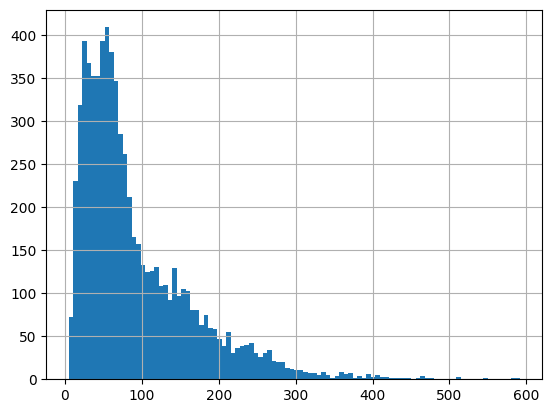

In [21]:
df_clearness_metrics["clearness_lap"].hist(bins=100)

<Axes: >

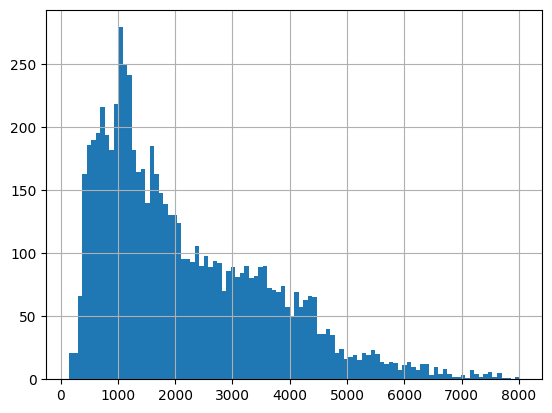

In [22]:
df_clearness_metrics["clearness_lap_downsize"].hist(bins=100)

<Axes: >

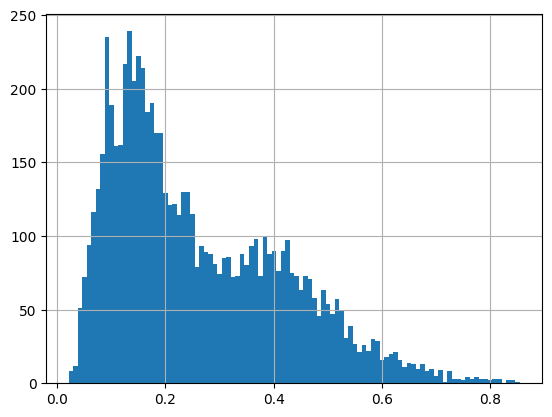

In [23]:
df_clearness_metrics["clearness_lap_multiscale"].hist(bins=100)

<Axes: >

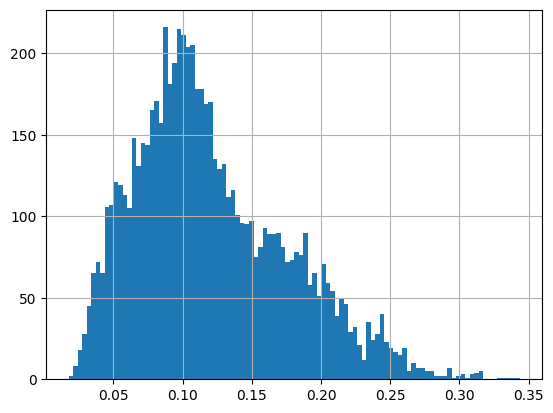

In [24]:
df_clearness_metrics["clearness_tenegrad"].hist(bins=100)

<Axes: >

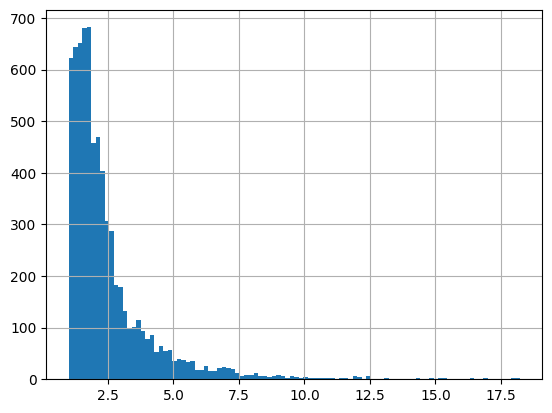

In [25]:
df_clearness_metrics["clearness_directional"].hist(bins=100)

In [26]:
df_ecc_sharp_scores = df_ecc.merge(df_clearness_metrics.rename({"name": "frame1"}, axis=1), on="frame1")

In [27]:
df_ecc_sharp_scores["clearness_lap_20q"] = df_ecc_sharp_scores["clearness_lap"] > df_ecc_sharp_scores["clearness_lap"].quantile(0.2)
df_ecc_sharp_scores["clearness_lap_downsize_20q"] = df_ecc_sharp_scores["clearness_lap_downsize"] > df_ecc_sharp_scores["clearness_lap_downsize"].quantile(0.2)
df_ecc_sharp_scores["clearness_lap_multiscale_20q"] = df_ecc_sharp_scores["clearness_lap_multiscale"] > df_ecc_sharp_scores["clearness_lap_multiscale"].quantile(0.2)
df_ecc_sharp_scores["clearness_tenegrad_20q"] = df_ecc_sharp_scores["clearness_tenegrad"] > df_ecc_sharp_scores["clearness_tenegrad"].quantile(0.2)
df_ecc_sharp_scores["clearness_directional_20q"] = df_ecc_sharp_scores["clearness_directional"] < df_ecc_sharp_scores["clearness_directional"].quantile(0.8)

In [28]:
(df_ecc_sharp_scores["clearness_directional"] < df_ecc_sharp_scores["clearness_directional"].quantile(0.8)).sum()

np.int64(5630)

In [ ]:
# from IPython.display import display
# from PIL import Image
# def visualize_df(df):
#     for idx, row in df.sample(frac=1).reset_index().iterrows():
#         if idx > 20: return
#         img = Image.open(row["frame1"])
#         display(img.resize((np.array(img.size) // 4)))
#         display(row)

# visualize_df(df_ecc_sharp_scores[np.logical_xor(df_ecc_sharp_scores["clearness_lap_downsize_20q"], df_ecc_sharp_scores["clearness_directional_20q"])])

<Axes: >

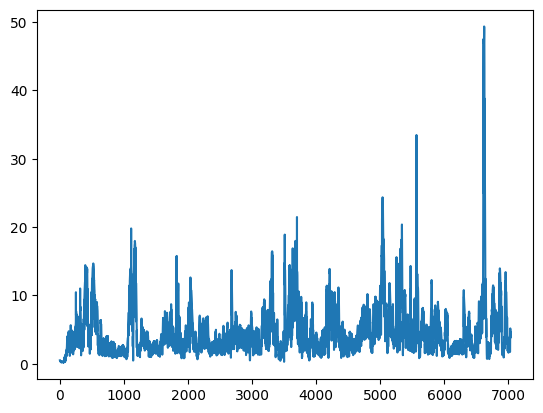

In [12]:
df_ecc["dist"].plot()

<Axes: >

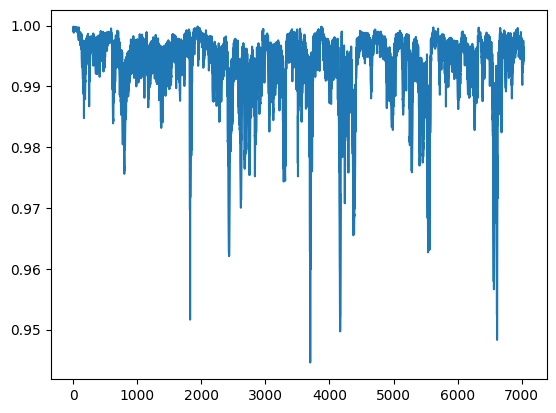

In [13]:
df_ecc["confidence"].plot()

In [33]:
df_ecc["frame1_clearness"] = df_clear[df_clear["name"].isin(df_ecc["frame1"])]["clearness"]

In [38]:
df_ecc_filtered =  df_ecc_sharp_scores[df_ecc_sharp_scores["clearness_lap_downsize"] > df_ecc_sharp_scores["clearness_lap_downsize"].quantile(0.2)]
# df_ecc_filtered =  [df_ecc["frame1_clearness"] > df_ecc["frame1_clearness"].quantile(0.2)]

In [42]:
# In each group, if there is an outlier in sharpness, pick it, thus trading motion consistency for sharpness. If all frames in a group have a simmilar sharpness, just pick the middle element
def pick_best_if_worth_it(g, value_col="frame1_clearness", upside_thresh=0.5, eps=1e-12):
    x = g[value_col].astype(float).to_numpy()
    n = len(g)

    if n == 0:
        return g
    
    mid_i = n // 2
    best_i = int(np.nanargmax(x))

    # robust scale for "typical variation" inside the group
    q1, q3 = np.nanpercentile(x, [25, 75])
    iqr = (q3 - q1)

    if not np.isfinite(iqr) or iqr < eps:
        upside = 0.0
    else:
        upside = (x[best_i] - x[mid_i]) / (iqr + eps) # "how many IQRs better than middle?"

    g["upside"] = upside
    g["middle_d"] = x[mid_i]
    g["best_d"] = x[best_i]
    g["best_idx"] = best_i - mid_i

    return g.iloc[[best_i]] if upside >= upside_thresh else g.iloc[[mid_i]]

def sample_local_distance(df, dist_interval, clearness_column="frame1_clearness"):
    df = df.copy()
    df["min_d_idx"] = (df["dist"].cumsum() / dist_interval).astype(int)
    df = df[["frame1", "dist", clearness_column, "min_d_idx"]].groupby("min_d_idx", group_keys=False)\
    .apply(lambda g: pick_best_if_worth_it(g, clearness_column) \
        .assign(dist=g["dist"].sum()).assign(n_frames=len(g))) \
        .reset_index(drop=True)
    return df
#TODO: Improve by accounting for the distance between the best and middle element. Meaning: If upside is good for moving 1 frame to the right, take it

In [40]:
df_ecc_filtered

,frame1,dist,confidence,clearness_lap,clearness_lap_downsize,clearness_lap_multiscale,clearness_tenegrad,clearness_directional,clearness_lap_20q,clearness_lap_downsize_20q,clearness_lap_multiscale_20q,clearness_tenegrad_20q,clearness_directional_20q
0,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,0.505984,0.999128,219.872724,3850.444746,0.448015,0.209755,1.741417,True,True,True,True,True
1,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,0.458429,0.999145,186.647083,3801.320902,0.429998,0.204685,1.725846,True,True,True,True,True
2,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,0.432256,0.999386,198.719524,3853.278535,0.435533,0.207752,1.740177,True,True,True,True,True
3,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,0.429129,0.999250,184.343641,3756.103154,0.427360,0.204708,1.729926,True,True,True,True,True
4,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,0.381756,0.999620,215.776822,3917.837668,0.447474,0.211514,1.750656,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7031,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,4.979588,0.994658,47.444931,1510.780044,0.209300,0.092326,2.309966,True,True,True,True,True
7032,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,4.393372,0.995290,40.713586,1252.048268,0.177470,0.078153,2.178998,True,True,True,True,True
7033,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,4.040500,0.995609,53.563488,1741.852082,0.213652,0.097295,1.651907,True,True,True,True,True
7034,/mnt/e/BA/scenes/vw_rain/orbit_frames_1/frame0...,3.811940,0.995084,60.478248,1828.058185,0.223774,0.102458,1.618432,True,True,True,True,True


In [44]:
df_ecc_filtered_60_ecc_dist = sample_local_distance(df_ecc_filtered, 60, clearness_column="clearness_lap_downsize")

/tmp/ipykernel_2203/652853882.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pick_best_if_worth_it(g, clearness_column) \


In [ ]:
df_ecc_filtered_60_ecc_dist

In [46]:
import shutil
from pathlib import Path
out = Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_ecc_lap_downsize_405/")
os.mkdir(out)
for idx, row in df_ecc_filtered_60_ecc_dist.iterrows():
    shutil.copy(row["frame1"], out / os.path.basename(row["frame1"])) 

In [62]:
df_ecc_filtered_60_ecc_dist.to_pickle("ecc_60_dist_80_percentile_sharp.pkl")

In [66]:
df_ecc_filtered_60_ecc_dist["frame1"].apply(os.path.basename)

0      frame00085.png
1      frame00113.png
2      frame00129.png
3      frame00153.png
4      frame00173.png
            ...      
405    frame06969.png
406    frame06985.png
407    frame06995.png
408    frame07021.png
409    frame07023.png
Name: frame1, Length: 410, dtype: object

In [ ]:
# df_dist["drop"] = df_dist["frame1"].isin(df_ecc_filtered_60_ecc_dist["frame1"].apply(os.path.basename))

In [70]:
df_dist.to_pickle("df_dist_drop_ecc_60_dist_80_percentile_sharp.pkl")

In [47]:
df_ecc_filtered.reset_index(drop=True).to_pickle("/home/roman/ba/envgs/preprocessing/ecc_dist_95_quant_clearness.pkl")

In [40]:
df_dist

,frame1,frame2,n_init_features,n_good_tracks,track_ratio,lk_err_median,backward_error,median_flow_magnitude,ransac_inlier_ratio,dist
0,frame00001.png,frame00002.png,1000,800,0.800,3.519204,0.001345,2.317356,1.000000,2.317356
1,frame00002.png,frame00003.png,1000,800,0.800,2.799603,0.000953,2.168385,1.000000,2.168385
2,frame00003.png,frame00004.png,1000,800,0.800,2.924851,0.000984,2.099410,1.000000,2.099410
3,frame00004.png,frame00005.png,1000,800,0.800,2.629075,0.000984,2.013533,1.000000,2.013533
4,frame00005.png,frame00006.png,1000,800,0.800,3.411919,0.001298,1.806599,1.000000,1.806599
...,...,...,...,...,...,...,...,...,...,...
7033,frame07034.png,frame07035.png,1000,797,0.797,2.687146,0.001968,22.131960,0.948557,22.174294
7034,frame07035.png,frame07036.png,1000,793,0.793,15.595876,0.111566,19.590446,0.962169,19.560150
7035,frame07036.png,frame07037.png,1000,795,0.795,12.140306,0.122853,20.505527,0.967296,20.551279
7036,frame07037.png,frame07038.png,1000,778,0.778,12.452877,0.148568,22.297028,0.924165,22.306976


In [41]:
df_clear["basename"] = df_clear["name"].apply(os.path.basename)

In [42]:
df_dist["frame1_clearness"] = df_dist["frame1"].apply(lambda p: df_clear[df_clear["basename"] == p]["clearness"].values[0])
df_dist["frame2_clearness"] = df_dist["frame2"].apply(lambda p: df_clear[df_clear["basename"] == p]["clearness"].values[0])

In [43]:
df_dist["clearness_sum"] = df_dist["frame1_clearness"] + df_dist["frame2_clearness"]

In [44]:
df_dist

,frame1,frame2,n_init_features,n_good_tracks,track_ratio,lk_err_median,backward_error,median_flow_magnitude,ransac_inlier_ratio,dist,frame1_clearness,frame2_clearness,clearness_sum
0,frame00001.png,frame00002.png,1000,800,0.800,3.519204,0.001345,2.317356,1.000000,2.317356,222.181583,188.746192,410.927775
1,frame00002.png,frame00003.png,1000,800,0.800,2.799603,0.000953,2.168385,1.000000,2.168385,188.746192,200.880099,389.626290
2,frame00003.png,frame00004.png,1000,800,0.800,2.924851,0.000984,2.099410,1.000000,2.099410,200.880099,186.410848,387.290947
3,frame00004.png,frame00005.png,1000,800,0.800,2.629075,0.000984,2.013533,1.000000,2.013533,186.410848,218.076581,404.487429
4,frame00005.png,frame00006.png,1000,800,0.800,3.411919,0.001298,1.806599,1.000000,1.806599,218.076581,182.533418,400.609999
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,frame07034.png,frame07035.png,1000,797,0.797,2.687146,0.001968,22.131960,0.948557,22.174294,53.674689,60.572792,114.247481
7034,frame07035.png,frame07036.png,1000,793,0.793,15.595876,0.111566,19.590446,0.962169,19.560150,60.572792,24.766307,85.339099
7035,frame07036.png,frame07037.png,1000,795,0.795,12.140306,0.122853,20.505527,0.967296,20.551279,24.766307,24.918352,49.684659
7036,frame07037.png,frame07038.png,1000,778,0.778,12.452877,0.148568,22.297028,0.924165,22.306976,24.918352,41.042590,65.960942


In [45]:
df_dist["clearness_min"] = df_dist[["frame1_clearness", "frame2_clearness"]].min(axis=1)

In [46]:
df_dist["clearness_min"].quantile(0.5)

np.float64(62.41879402512892)

In [47]:
clear_frames = df_clear[df_clear["clearness"] >= 150]

<Axes: >

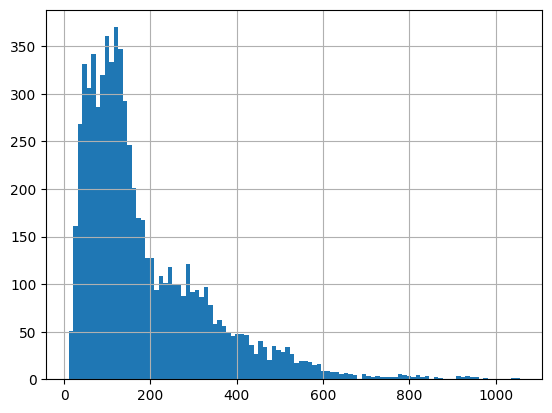

In [48]:
df_dist["clearness_sum"].hist(bins=100)

In [172]:
df_dist["frame1_clearness"].quantile(0.05)

np.float64(17.839762636728246)

In [240]:
filtered_dist = filtered_dist[filtered_dist["frame1_clearness"] > filtered_dist["frame1_clearness"].quantile(0.05)]

In [241]:
filtered_dist

,frame1,dist,frame1_clearness,min_d_idx,upside,middle_d,best_d,best_idx,n_frames
0,frame00085.png,348.637966,305.899142,0,1.555091,250.642084,305.899142,26,117
1,frame00129.png,347.590988,156.686326,1,1.757295,114.932193,156.686326,-3,28
2,frame00153.png,334.863875,189.829971,2,3.379754,91.666885,189.829971,-7,28
3,frame00177.png,354.355179,94.242023,3,1.917873,78.110523,94.242023,-4,15
4,frame00197.png,346.148582,93.956135,4,0.169204,93.956135,97.115253,-6,17
...,...,...,...,...,...,...,...,...,...
377,frame06963.png,365.055161,72.428266,377,1.635004,54.809031,72.428266,1,9
378,frame06975.png,340.278751,154.316760,378,0.975646,112.825970,154.316760,2,13
379,frame06995.png,366.428575,347.196055,379,0.000000,347.196055,347.196055,0,30
380,frame07021.png,348.033574,208.841169,380,8.749347,67.987253,208.841169,1,20


In [242]:
df_dist["drop"] = df_dist["frame1"].isin(filtered_dist["frame1"])

In [231]:
filtered_dist["frame1"] = filtered_dist["frame1"].apply(lambda p: "/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_flow_250_local/" + p)

/tmp/ipykernel_2457/1085574568.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_dist["frame1"] = filtered_dist["frame1"].apply(lambda p: "/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_flow_250_local/" + p)


In [211]:
filtered_dist.to_pickle("350_dist_group_5_quantile_clearness_05_upside.pkl")

In [ ]:
#NOTE: What is better? to aggregate using smaller distance and filter out more frames based on clearness or aggregate based on larger distance and filter less

In [ ]:
# Optimize min_d vs clearness_quartile vs upside_thresh

In [246]:
df_dist

,frame1,frame2,n_init_features,n_good_tracks,track_ratio,lk_err_median,backward_error,median_flow_magnitude,ransac_inlier_ratio,dist,frame1_clearness,frame2_clearness,clearness_sum,clearness_min,min_d_idx,drop
0,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,800,0.800,3.519204,0.001345,2.317356,1.000000,2.317356,222.181583,188.746192,410.927775,188.746192,0,False
1,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,800,0.800,2.799603,0.000953,2.168385,1.000000,2.168385,188.746192,200.880099,389.626290,188.746192,0,False
2,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,800,0.800,2.924851,0.000984,2.099410,1.000000,2.099410,200.880099,186.410848,387.290947,186.410848,0,False
3,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,800,0.800,2.629075,0.000984,2.013533,1.000000,2.013533,186.410848,218.076581,404.487429,186.410848,0,False
4,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,800,0.800,3.411919,0.001298,1.806599,1.000000,1.806599,218.076581,182.533418,400.609999,182.533418,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,797,0.797,2.687146,0.001968,22.131960,0.948557,22.174294,53.674689,60.572792,114.247481,53.674689,381,False
7034,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,793,0.793,15.595876,0.111566,19.590446,0.962169,19.560150,60.572792,24.766307,85.339099,24.766307,381,True
7035,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,795,0.795,12.140306,0.122853,20.505527,0.967296,20.551279,24.766307,24.918352,49.684659,24.766307,381,False
7036,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...,1000,778,0.778,12.452877,0.148568,22.297028,0.924165,22.306976,24.918352,41.042590,65.960942,24.918352,381,False


In [ ]:
filtered_dist["n_frames"].describe()

count    535.000000
mean      13.155140
std        9.532531
min        1.000000
25%        7.000000
50%       11.000000
75%       17.000000
max      109.000000
Name: n_frames, dtype: float64

<Axes: >

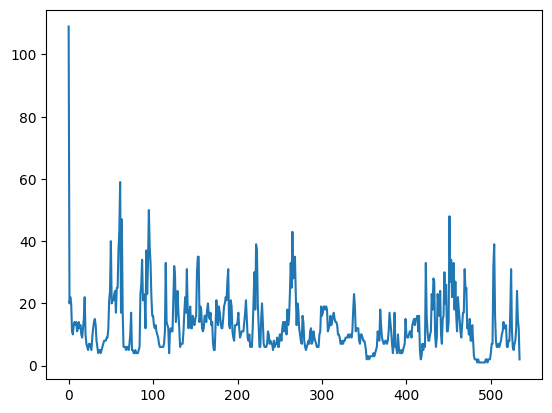

In [ ]:
filtered_dist["n_frames"].plot()

In [244]:
df_dist["frame1"] = df_dist["frame1"].apply(lambda p: "/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_flow_250_local/" + p)
df_dist["frame2"] = df_dist["frame2"].apply(lambda p: "/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_flow_250_local/" + p)

In [245]:
df_dist.to_pickle("all_frames_drop_350_dist_05_upside.pkl")

In [ ]:
import shutil
out_dir = Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_optical_flow_250_local")
os.mkdir(out_dir)
filtered_dist["frame1"].apply(lambda file_name: shutil.copy2(Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_1") / file_name, out_dir / file_name))

min_d_idx
0      /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
1      /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
2      /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
3      /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
4      /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
                             ...                        
530    /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
531    /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
532    /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
533    /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
534    /mnt/e/BA/scenes/vw_rain/orbit_frames_optical_...
Name: frame1, Length: 535, dtype: object

In [22]:
# ORB matching

In [ ]:
with ThreadPoolExecutor() as executor:
    orb_out_lists = list(tqdm(executor.map(match_features_between_frames, frames), total=len(frames)))


In [ ]:
# don't forget to filter quantile of clearness

In [10]:
from scipy import stats

In [13]:
stats.pearsonr(df_dist["lk_err_median"], df_dist["median_flow_magnitude"])

PearsonRResult(statistic=np.float64(0.22525680179933188), pvalue=np.float64(1.1600979371309684e-81))

In [14]:
stats.pearsonr(df_dist["lk_err_median"], df_dist["clearness_sum"])

PearsonRResult(statistic=np.float64(-0.08388908071392873), pvalue=np.float64(1.8038180475507685e-12))

In [15]:
stats.pearsonr(df_dist["median_flow_magnitude"], df_dist["clearness_sum"])

PearsonRResult(statistic=np.float64(-0.4004467089949401), pvalue=np.float64(2.1848325562460282e-269))

In [ ]:
# Filter Optical Flow results. NOTE: Inconsistent results
df_dist["drop"] = df_dist["backward_error"] >= df_dist["backward_error"].quantile(0.95)
df_dist["drop"] = np.logical_or(df_dist["drop"], df_dist["ransac_inlier_ratio"] <= df_dist["ransac_inlier_ratio"].quantile(0.05))
df_dist["drop"] = np.logical_or(df_dist["drop"], df_dist["clearness_sum"] <= df_dist["clearness_sum"].quantile(0.05))

In [ ]:
df_dist['dist'] = df_dist['dist'].where(~df_dist["drop"]).ffill()  # replace bad results with last known good frame motion

In [ ]:
df_dist["frame1_clearness"].hist(bins=100)

In [ ]:
df_dist["frame1_clearness"].quantile(0.8)

In [ ]:
# Goals:
# 1. Select only clear frames
# 2. Try to keep distances between frames consistent
# 3. Sample N frames
#
# What if the motion between segments is too big. What do we do then?
# What we really need is to measure how many "unique" pixels or unique camera angles we have to sample. That probably means SfM for all images.
#
#
# What do we want?
# 1. Good clear gt frames
# 2. Allow more unique frames to hopefully get a uniform capture
#
# What if a lot of frames are bad? Do we keep some or not -> We don't include blurry frames, so we set a global threshold for clearness of frames and ignore everything else. Let's say we set it to 150 (Laplacian Variance)
# What if we have a lot of clear frames near one another and we still have to sample more -> We drop nearby frames, don't include them? I think we need to include them uniformly
# Is it bad that we include neighboring frames? No, but we have to let the user know that this is the case and try to sample neighboring frames where the gaps between them are higher to maximize the information gain
#
# The original approach was to run optical flow between all pairs of frames, calculate the median flow and treat is the motion between frames. The assumption was that the motion of the operator during the capture of the video was not uniform,
# so we have to compensate for that in the sampling. But that's not really the case and we also filmed at 60 fps, so there's plenty of frames with low-motion. However things like blur drastically change the median flow results and we end up oversampling bad blurry regions because of that
# Solution? Drop all blurry frames and do optical flow again. Problem: we don't know how many blurry frames we dropped between good ones, so the motion might have been too big for classical optical flow
#
# One way of doing it would be to set a target N of frames. Then, using semantic embeddings or optical flow we estimate 

In [ ]:
clear_frames = df_clear[df_clear["clearness"] >= 150]

In [ ]:
import shutil
out_dir = Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_1_clear")
os.mkdir(out_dir)
clear_frames["name"].apply(lambda src: shutil.copy2(src, out_dir / src.name))

In [ ]:
clear_frames_list = clear_frames["name"].to_list()

In [ ]:
len(clear_frames_list)

In [ ]:
clear_frame_pairs = list(zip(clear_frames_list,clear_frames_list[1:]))

In [ ]:
with ThreadPoolExecutor() as executor:
    clear_frames_dist = list(tqdm(executor.map(match_features_between_frames, clear_frame_pairs), total=len(clear_frame_pairs)))

In [ ]:
clear_frames_df = pd.DataFrame(clear_frames_dist)

In [ ]:
clear_frames_df

In [ ]:
clear_frames_df["n_inliers"].hist(bins=100)

In [ ]:
clear_frames_df["drop"] = clear_frames_df["n_inliers"] <= clear_frames_df["n_inliers"].quantile(0.05)

In [ ]:
clear_frames_df['dist'] = clear_frames_df['dist'].where(~clear_frames_df["drop"]).ffill()  # replace bad results with last known good frame motion

In [ ]:
clear_frames_df

In [ ]:
df_clear["name"].loc[0]

In [ ]:
clear_frames_df["frame1_clearness"] = clear_frames_df["frame1"].apply(lambda p: df_clear[df_clear["name"] == Path(p)]["clearness"].values[0])
clear_frames_df["frame2_clearness"] = clear_frames_df["frame2"].apply(lambda p: df_clear[df_clear["name"] == Path(p)]["clearness"].values[0])

In [ ]:
clear_frames_df.to_pickle("orb_match_vw_rain_clear_frames.pkl")

In [ ]:
clear_frames_df = pkl.loads(Path("orb_match_vw_rain_clear_frames.pkl").read_bytes())

In [ ]:
clear_frames_df["dist"].quantile(0.5)

In [ ]:
clear_frames_df["dist"] > clear_frames_df["dist"].quantile(0.5)

In [ ]:
clear_frames_df

In [ ]:
step = 100  # keep ~one sample per 0.5 distance units (tune this)

df = clear_frames_df

df = df.sort_values("frame1").reset_index(drop=True)
keep = [0]
acc = 0.0

for i in range(1, len(df)):
    acc += float(df.loc[i, "dist"])
    if acc >= step:
        keep.append(i)
        acc = 0.0

if keep[-1] != len(df) - 1:
    keep.append(len(df) - 1)

df_down = df.iloc[keep].copy()

max_gap = 10  # keep at least every 10 rows
forced = np.arange(0, len(df), max_gap)

idx2 = np.unique(np.r_[df_down.index.to_numpy(), forced, len(df)-1])
df_down = df.loc[idx2].sort_index().reset_index(drop=True)


In [ ]:
df_down

In [ ]:
import shutil
out_dir = Path("/mnt/e/BA/scenes/vw_rain/orbit_frames_1_clear_366")
os.mkdir(out_dir)
df_down["frame1"].apply(lambda src: shutil.copy2(src, out_dir / Path(src).name))

In [ ]:
clear_frames_df["50_qantile_dist"] = clear_frames_df["dist"] > clear_frames_df["dist"].quantile(0.5)

In [ ]:
clear_frames_df[clear_frames_df["50_qantile_dist"]]

In [ ]:
dist_per_segment = clear_frames_df["dist"].sum() / 300

In [ ]:
clear_frames_df["dist"].sum()

In [ ]:
clear_frames_df["dist"].hist(bins=100)

In [ ]:
clear_frames_df[clear_frames_df["dist"] <= clear_frames_df["dist"].quantile(0.96)]["dist"].sum()

In [ ]:
clear_frames_df

In [ ]:
clear_frames_df["cum_dist"] = clear_frames_df["dist"].cumsum()

In [ ]:
clear_frames_df["cum_dist"] / 15

In [ ]:
df_dist["cum_motion"] = df_dist["dist"].cumsum()

In [ ]:
df_dist[df_dist["frame1_clearness"] >= df_dist["frame1_clearness"].quantile(0.8)]

In [ ]:
toatal_dist = df_dist["dist"].sum()

In [ ]:
n_segments = 300

In [ ]:
motion_per_segment = toatal_dist / n_segments

In [ ]:
motion_per_segment

In [ ]:
df_dist["motion_segment"] = np.floor(df_dist["cum_motion"] / motion_per_segment).astype(int)

In [ ]:
sample_idx = df_dist.groupby("motion_segment")["frame1_clearness"].idxmax()

In [ ]:
df_dist.loc[sample_idx]

In [ ]:
df_dist["dist"].cumsum() % motion_per_segment

In [ ]:
df_clear["clearness"].hist(bins=100)

In [ ]:
df_clear["clearness"].cumsum()

In [ ]:
df_clear.loc[2]["name"]

In [ ]:
df_clear["clearness"].describe()

In [ ]:
df_clear[df_clear["clearness"] <= 93]

In [ ]:
from PIL import Image

In [ ]:
Image.open(df_clear.loc[116]["name"])

In [ ]:
df.to_pickle("distances_vw_rain_all_frames.pkl")

In [ ]:
df["lk_err_median:"].hist(bins=100)

In [ ]:
distances = [np.nan if d is None else d for d in distances]

In [ ]:
df_dist[df_dist["median_flow_magnitude"] >= 241.980209]

In [ ]:
frames = sorted(list(frames_root.iterdir()))

In [ ]:
frame_pair = frames[6620:6622]

In [ ]:
frame1_path, frame2_path = frame_pair
img1_bgr = cv2.imread(frame1_path)
img2_bgr = cv2.imread(frame2_path)

img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

In [ ]:
plt.imshow(img1_gray)

In [ ]:
plt.imshow(img2_gray)

In [ ]:
p0 = cv2.goodFeaturesToTrack(
        img1_gray,
        maxCorners=1000,
        qualityLevel=0.01,
        minDistance=7,
        blockSize=7
    )

In [ ]:
def draw_points(img, points):
    img_with_points = img.copy()
    pts = np.asarray(points).reshape(-1, 2).astype(int)  # (N,1,2) -> (N,2)
    for x, y in pts:
        cv2.circle(img_with_points, (x, y), 1, 255, 50, lineType=cv2.LINE_AA)

    return img_with_points

In [ ]:
p0.shape

In [ ]:
# Visualize features
plt.imshow(draw_points(img1_bgr, p0))

In [ ]:
np.array((255,0,0), dtype=np.uint8)

In [ ]:
p1, st, err = cv2.calcOpticalFlowPyrLK(
    img1_gray,
    img2_gray,
    p0,
    None,
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

In [ ]:
pd.Series(err.reshape(-1)).hist(bins=100)

In [ ]:
p1

In [ ]:
pts1 = p0.reshape(-1, 2).astype(np.float32)
pts2 = p1.reshape(-1, 2).astype(np.float32)

In [ ]:
F, mask = cv2.findFundamentalMat(
    pts1,
    pts2,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=2.0,
    confidence=0.99
)  #RANSAC

In [ ]:
mask.shape